# Neural Melody Generator (LSTM → Transformer comparison)

In [1]:
import torch
import music21
import pretty_midi
import numpy as np

print("Torch version:", torch.__version__)
print("All imports successful!")

Torch version: 2.14.0+cpu
All imports successful!


## Setup Log
Created conda environment (./env) with Python + numpy, matplotlib, jupyter
Installed PyTorch via pip (conda had an archive extraction bug on Windows)
Installed music21, pretty_midi for MIDI handling
Verified all imports working
Initialized git, pushed first commit to GitHub

In [2]:
import os

data_path = "data/clean_midi"
artists = os.listdir(data_path)
print("Number of artists:", len(artists))
print("First 10 artists:", artists[:10])

Number of artists: 2200
First 10 artists: ['.38 Special', '10,000 Maniacs', '101 Strings', '10cc', '1910 Fruitgum Company', '2 Brothers on the 4th Floor', '2 the Core', '2 Unlimited', '20 Fingers', '2Boys']


In [3]:
import pretty_midi
import os

# Pick a real artist and see what songs they have
artist = "10cc"
artist_path = os.path.join(data_path, artist)
songs = os.listdir(artist_path)
print("Songs by", artist, ":", songs)

Songs by 10cc : ['Dreadlock Holiday.1.mid', 'Dreadlock Holiday.2.mid', 'Dreadlock Holiday.3.mid', 'Dreadlock Holiday.4.mid', 'Dreadlock Holiday.mid', "I'm Not In Love.1.mid", "I'm Not In Love.2.mid", "I'm Not In Love.3.mid", "I'm Not In Love.mid", 'The Things We Do for Love.mid']


In [4]:
song_path = os.path.join(artist_path, "Dreadlock Holiday.mid")

midi_data = pretty_midi.PrettyMIDI(song_path)

print("Song duration (seconds):", midi_data.get_end_time())
print("Number of instruments:", len(midi_data.instruments))

for i, instrument in enumerate(midi_data.instruments):
    instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
    print(f"Instrument {i}: {instrument_name} | Drum track: {instrument.is_drum} | Notes: {len(instrument.notes)}")

Song duration (seconds): 307.736506875
Number of instruments: 9
Instrument 0: Acoustic Grand Piano | Drum track: True | Notes: 3282
Instrument 1: Acoustic Grand Piano | Drum track: False | Notes: 473
Instrument 2: Acoustic Grand Piano | Drum track: False | Notes: 456
Instrument 3: Acoustic Grand Piano | Drum track: False | Notes: 2851
Instrument 4: Acoustic Grand Piano | Drum track: False | Notes: 3369
Instrument 5: Acoustic Grand Piano | Drum track: False | Notes: 1626
Instrument 6: Acoustic Grand Piano | Drum track: False | Notes: 2939
Instrument 7: Acoustic Grand Piano | Drum track: False | Notes: 244
Instrument 8: Acoustic Grand Piano | Drum track: False | Notes: 426


In [5]:
# Find the non-drum instrument with the most notes
melodic_instruments = [inst for inst in midi_data.instruments if not inst.is_drum]
main_instrument = max(melodic_instruments, key=lambda inst: len(inst.notes))

print("Chosen instrument index:", midi_data.instruments.index(main_instrument))
print("Number of notes:", len(main_instrument.notes))

# Look at the first 10 notes
for note in main_instrument.notes[:10]:
    print(f"Pitch: {note.pitch}, Start: {note.start:.2f}s, End: {note.end:.2f}s, Velocity: {note.velocity}")

Chosen instrument index: 4
Number of notes: 3369
Pitch: 62, Start: 4.52s, End: 6.17s, Velocity: 27
Pitch: 70, Start: 4.61s, End: 6.18s, Velocity: 60
Pitch: 74, Start: 4.65s, End: 6.18s, Velocity: 91
Pitch: 67, Start: 4.58s, End: 6.18s, Velocity: 64
Pitch: 62, Start: 6.31s, End: 6.62s, Velocity: 32
Pitch: 72, Start: 6.40s, End: 6.64s, Velocity: 73
Pitch: 65, Start: 6.35s, End: 6.65s, Velocity: 64
Pitch: 69, Start: 6.37s, End: 6.66s, Velocity: 60
Pitch: 58, Start: 6.94s, End: 9.24s, Velocity: 40
Pitch: 63, Start: 6.97s, End: 9.24s, Velocity: 73


In [6]:
# Extract melody: keep only the highest-pitch note at each unique start time
from collections import defaultdict

notes_by_start = defaultdict(list)
for note in main_instrument.notes:
    notes_by_start[round(note.start, 2)].append(note)

melody_notes = []
for start_time in sorted(notes_by_start.keys()):
    notes_at_time = notes_by_start[start_time]
    highest_note = max(notes_at_time, key=lambda n: n.pitch)
    melody_notes.append(highest_note)

print("Original note count:", len(main_instrument.notes))
print("Melody-only note count:", len(melody_notes))

# Preview first 10 melody notes
for note in melody_notes[:10]:
    print(f"Pitch: {note.pitch}, Start: {note.start:.2f}s, Duration: {note.end - note.start:.2f}s")

Original note count: 3369
Melody-only note count: 2292
Pitch: 62, Start: 4.52s, Duration: 1.65s
Pitch: 67, Start: 4.58s, Duration: 1.60s
Pitch: 70, Start: 4.61s, Duration: 1.57s
Pitch: 74, Start: 4.65s, Duration: 1.53s
Pitch: 62, Start: 6.31s, Duration: 0.31s
Pitch: 65, Start: 6.35s, Duration: 0.31s
Pitch: 69, Start: 6.37s, Duration: 0.29s
Pitch: 72, Start: 6.40s, Duration: 0.23s
Pitch: 58, Start: 6.94s, Duration: 2.29s
Pitch: 63, Start: 6.97s, Duration: 2.27s


In [7]:
# Group notes into chords using a time tolerance window
tolerance = 0.05  # 50ms — notes within this window count as the same chord

sorted_notes = sorted(main_instrument.notes, key=lambda n: n.start)

melody_notes = []
i = 0
while i < len(sorted_notes):
    current_group = [sorted_notes[i]]
    j = i + 1
    while j < len(sorted_notes) and sorted_notes[j].start - sorted_notes[i].start < tolerance:
        current_group.append(sorted_notes[j])
        j += 1
    highest_note = max(current_group, key=lambda n: n.pitch)
    melody_notes.append(highest_note)
    i = j

print("Original note count:", len(main_instrument.notes))
print("Melody-only note count:", len(melody_notes))

for note in melody_notes[:10]:
    print(f"Pitch: {note.pitch}, Start: {note.start:.2f}s, Duration: {note.end - note.start:.2f}s")

Original note count: 3369
Melody-only note count: 1058
Pitch: 62, Start: 4.52s, Duration: 1.65s
Pitch: 70, Start: 4.61s, Duration: 1.57s
Pitch: 74, Start: 4.65s, Duration: 1.53s
Pitch: 65, Start: 6.35s, Duration: 0.31s
Pitch: 72, Start: 6.40s, Duration: 0.23s
Pitch: 70, Start: 6.98s, Duration: 2.26s
Pitch: 74, Start: 9.31s, Duration: 1.69s
Pitch: 72, Start: 11.05s, Duration: 0.29s
Pitch: 63, Start: 11.63s, Duration: 2.33s
Pitch: 70, Start: 11.65s, Duration: 2.30s


In [8]:

tolerance = 0.15  # widened to 150ms

sorted_notes = sorted(main_instrument.notes, key=lambda n: n.start)

melody_notes = []
i = 0
while i < len(sorted_notes):
    current_group = [sorted_notes[i]]
    j = i + 1
    while j < len(sorted_notes) and sorted_notes[j].start - sorted_notes[i].start < tolerance:
        current_group.append(sorted_notes[j])
        j += 1
    highest_note = max(current_group, key=lambda n: n.pitch)
    melody_notes.append(highest_note)
    i = j

print("Original note count:", len(main_instrument.notes))
print("Melody-only note count:", len(melody_notes))

for note in melody_notes[:10]:
    print(f"Pitch: {note.pitch}, Start: {note.start:.2f}s, Duration: {note.end - note.start:.2f}s")



Original note count: 3369
Melody-only note count: 933
Pitch: 74, Start: 4.65s, Duration: 1.53s
Pitch: 72, Start: 6.40s, Duration: 0.23s
Pitch: 70, Start: 6.98s, Duration: 2.26s
Pitch: 74, Start: 9.31s, Duration: 1.69s
Pitch: 72, Start: 11.05s, Duration: 0.29s
Pitch: 70, Start: 11.65s, Duration: 2.30s
Pitch: 55, Start: 13.98s, Duration: 0.26s
Pitch: 70, Start: 14.31s, Duration: 0.12s
Pitch: 70, Start: 14.44s, Duration: 0.01s
Pitch: 70, Start: 14.86s, Duration: 0.06s


In [9]:
def extract_melody_from_midi(midi_path, tolerance=0.15):
    """
    Loads a MIDI file and extracts a melody-only note sequence
    (collapses chords into their highest-pitch note).
    Returns None if the file can't be processed (corrupted/unreadable).
    """
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
    except Exception as e:
        return None  # some Lakh files are corrupted or malformed

    # pick non-drum instrument with the most notes
    melodic_instruments = [inst for inst in midi_data.instruments if not inst.is_drum]
    if not melodic_instruments:
        return None  # no melodic instrument found

    main_instrument = max(melodic_instruments, key=lambda inst: len(inst.notes))
    if len(main_instrument.notes) == 0:
        return None

    sorted_notes = sorted(main_instrument.notes, key=lambda n: n.start)

    melody_notes = []
    i = 0
    while i < len(sorted_notes):
        current_group = [sorted_notes[i]]
        j = i + 1
        while j < len(sorted_notes) and sorted_notes[j].start - sorted_notes[i].start < tolerance:
            current_group.append(sorted_notes[j])
            j += 1
        highest_note = max(current_group, key=lambda n: n.pitch)
        melody_notes.append(highest_note)
        i = j

    return melody_notes


# Test it on the same song to confirm it matches our earlier output
test_path = os.path.join(data_path, "10cc", "Dreadlock Holiday.mid")
result = extract_melody_from_midi(test_path)
print("Notes extracted:", len(result))
for note in result[:5]:
    print(f"Pitch: {note.pitch}, Start: {note.start:.2f}s")

Notes extracted: 933
Pitch: 74, Start: 4.65s
Pitch: 72, Start: 6.40s
Pitch: 70, Start: 6.98s
Pitch: 74, Start: 9.31s
Pitch: 72, Start: 11.05s


In [10]:
import glob

# Find all .mid files across all artists (this just lists paths, doesn't load them yet)
all_midi_files = glob.glob(os.path.join(data_path, "**", "*.mid"), recursive=True)
print("Total MIDI files found:", len(all_midi_files))

# Take a small sample to start
sample_files = all_midi_files[:50]
print("Sample size:", len(sample_files))
print("First few files:", sample_files[:3])

Total MIDI files found: 17167
Sample size: 50
First few files: ['data/clean_midi\\10,000 Maniacs\\A Campfire Song.mid', 'data/clean_midi\\101 Strings\\Theme From The Godfather.mid', 'data/clean_midi\\10cc\\Dreadlock Holiday.1.mid']


In [11]:
processed_melodies = []
failed_files = []

for file_path in sample_files:
    melody = extract_melody_from_midi(file_path)
    if melody is not None and len(melody) > 0:
        processed_melodies.append({"file": file_path, "melody": melody})
    else:
        failed_files.append(file_path)

print(f"Successfully processed: {len(processed_melodies)} / {len(sample_files)}")
print(f"Failed: {len(failed_files)}")
if failed_files:
    print("Example failed files:", failed_files[:5])

C:\Users\chSw907\Documents\Neural_Melody_Generator\env\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully processed: 49 / 50
Failed: 1
Example failed files: ['data/clean_midi\\10cc\\Dreadlock Holiday.4.mid']


*49/50 succeeded — that's a healthy 98% success rate, and exactly the kind of real-world messiness we expected (Lakh is known to have some corrupted/unusual files). Our error handling did its job — the pipeline didn't crash, it just skipped the bad file and kept going. *"built the pipeline defensively since real datasets have corrupted files, and measured a 98% success rate on a sample."

Progress Log update
Built reusable extract_melody_from_midi() function — wraps chord-to-melody extraction with error handling for corrupted/malformed files.
Tested on a sample of 50 songs — 49/50 processed successfully (98% success rate), confirming the pipeline handles real-world messy data gracefully.

In [12]:
# Collect all pitches across all processed melodies
all_pitches = set()
for item in processed_melodies:
    for note in item["melody"]:
        all_pitches.add(note.pitch)

# Build vocabulary: pitch -> integer token
vocab = sorted(all_pitches)
pitch_to_token = {pitch: i for i, pitch in enumerate(vocab)}
token_to_pitch = {i: pitch for i, pitch in enumerate(vocab)}

print("Vocabulary size (unique pitches):", len(vocab))
print("Pitch range:", min(vocab), "to", max(vocab))
print("Sample mapping:", {k: pitch_to_token[k] for k in list(pitch_to_token)[:5]})

Vocabulary size (unique pitches): 65
Pitch range: 25 to 93
Sample mapping: {25: 0, 27: 1, 28: 2, 29: 3, 30: 4}


In [13]:
# Convert each song's melody (list of Note objects) into a list of integer tokens
tokenized_songs = []
for item in processed_melodies:
    tokens = [pitch_to_token[note.pitch] for note in item["melody"]]
    tokenized_songs.append(tokens)

print("Number of tokenized songs:", len(tokenized_songs))
print("First song length (notes):", len(tokenized_songs[0]))
print("First 20 tokens of first song:", tokenized_songs[0][:20])

Number of tokenized songs: 49
First song length (notes): 373
First 20 tokens of first song: [48, 40, 40, 41, 40, 38, 38, 40, 38, 36, 36, 40, 40, 40, 38, 38, 36, 40, 40, 43]


In [14]:
sequence_length = 50  # how many past notes the model sees before predicting the next

input_sequences = []
target_notes = []

for tokens in tokenized_songs:
    if len(tokens) <= sequence_length:
        continue  # skip songs too short to form even one training example
    for i in range(len(tokens) - sequence_length):
        input_sequences.append(tokens[i : i + sequence_length])
        target_notes.append(tokens[i + sequence_length])

print("Total training examples:", len(input_sequences))
print("Example input (first 10 of 50 tokens):", input_sequences[0][:10])
print("Example target (the note that follows):", target_notes[0])

Total training examples: 26377
Example input (first 10 of 50 tokens): [48, 40, 40, 41, 40, 38, 38, 40, 38, 36]
Example target (the note that follows): 40


Progress Log update
Built vocabulary — mapped 65 unique MIDI pitches (range 25-93) to integer tokens, similar to word→ID mapping in NLP.
Tokenized all processed songs — converted each song's melody into a sequence of integer tokens.
Created training sequences — used a sliding window (50 notes → predict next note) to generate input/target pairs, producing 26,377 training examples from 49 songs.

In [15]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # standard loss for classification-style prediction (predicting which note comes next)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam is a reliable default optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Training on:", device)

NameError: name 'nn' is not defined

# dataset creation + model + training setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 1. Dataset and DataLoader
class MelodyDataset(Dataset):
    def __init__(self, input_sequences, target_notes):
        self.inputs = torch.tensor(input_sequences, dtype=torch.long)
        self.targets = torch.tensor(target_notes, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = MelodyDataset(input_sequences, target_notes)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# 2. Model
class MelodyLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=2):
        super(MelodyLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        last_output = lstm_out[:, -1, :]
        logits = self.fc(last_output)
        return logits

vocab_size = len(vocab)
model = MelodyLSTM(vocab_size)

# 3. Loss, optimizer, device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Setup complete. Training on:", device)
print("Dataset size:", len(dataset))

# start training

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    for batch_inputs, batch_targets in dataloader:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

        optimizer.zero_grad()
        outputs = model(batch_inputs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    for batch_inputs, batch_targets in dataloader:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

        optimizer.zero_grad()
        outputs = model(batch_inputs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

In [ ]:
def generate_melody(model, seed_sequence, length=100, temperature=1.0):
    model.eval()
    generated = list(seed_sequence)
    
    with torch.no_grad():
        for _ in range(length):
            input_seq = torch.tensor([generated[-50:]], dtype=torch.long).to(device)
            logits = model(input_seq)
            probabilities = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probabilities, 1).item()
            generated.append(next_token)
    
    return generated

# Use the first 50 tokens of a real song as a seed
seed = input_sequences[0]
generated_tokens = generate_melody(model, seed, length=100, temperature=1.0)

print("Generated token sequence (first 30):", generated_tokens[:30])
print("Original seed (last 10 tokens for reference):", seed[-10:])


In [ ]:
from sklearn.model_selection import train_test_split

# Split into train/validation (80/20)
train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    input_sequences, target_notes, test_size=0.2, random_state=42
)

train_dataset = MelodyDataset(train_inputs, train_targets)
val_dataset = MelodyDataset(val_inputs, val_targets)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))

# Progress Log update
Discovered and fixed data leakage in evaluation — initial training (no train/val split) showed suspiciously low loss (~0.08); generated output confirmed the model was memorizing training sequences rather than learning general patterns, due to heavy overlap in the sliding-window examples.
Implemented proper train/validation split (80/20) and retrained from a fresh model — resulting in a realistic, healthy loss curve (train: 1.77→0.27, val: 1.24→0.30) with no signs of divergence.

In [ ]:
# Re-initialize a fresh model so we're not continuing to train the already-overfit one
model = MelodyLSTM(vocab_size)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    total_train_loss = 0
    for batch_inputs, batch_targets in train_loader:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

        optimizer.zero_grad()
        outputs = model(batch_inputs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_inputs, batch_targets in val_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            outputs = model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

In [ ]:
def generate_melody(model, seed_sequence, length=100, temperature=1.0):
    model.eval()
    generated = list(seed_sequence)
    
    with torch.no_grad():
        for _ in range(length):
            input_seq = torch.tensor([generated[-50:]], dtype=torch.long).to(device)
            logits = model(input_seq)
            probabilities = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probabilities, 1).item()
            generated.append(next_token)
    
    return generated

# Use a real seed from validation data (data the model wasn't trained on)
seed = val_inputs[0]
generated_tokens = generate_melody(model, seed, length=100, temperature=1.0)

print("Seed (first 10 tokens):", seed[:10])
print("Generated continuation (next 20 tokens):", generated_tokens[50:70])

In [ ]:
# Find a seed with more pitch variety (not just one repeated note)
import numpy as np

varied_seed = None
for seq in val_inputs:
    if len(set(seq)) > 10:  # at least 10 different pitches in the sequence
        varied_seed = seq
        break

print("Varied seed sample:", varied_seed[:15])
print("Unique pitches in this seed:", len(set(varied_seed)))

# Generate with this better seed, try temperature 1.0 first
generated_tokens = generate_melody(model, varied_seed, length=100, temperature=1.0)
print("\nGenerated continuation (tokens 50-80):", generated_tokens[50:80])

# Also try a higher temperature for comparison (more randomness/creativity)
generated_tokens_hot = generate_melody(model, varied_seed, length=100, temperature=1.2)
print("\nGenerated with higher temperature (tokens 50-80):", generated_tokens_hot[50:80])

In [ ]:
import pretty_midi

def tokens_to_midi(tokens, token_to_pitch, output_path, note_duration=0.3):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # 0 = Acoustic Grand Piano

    start_time = 0.0
    for token in tokens:
        pitch = token_to_pitch[token]
        note = pretty_midi.Note(
            velocity=80,
            pitch=pitch,
            start=start_time,
            end=start_time + note_duration
        )
        instrument.notes.append(note)
        start_time += note_duration

    midi.instruments.append(instrument)
    midi.write(output_path)
    print(f"Saved MIDI file to {output_path}")

# Save the temperature 1.0 generated melody
tokens_to_midi(generated_tokens, token_to_pitch, "generated_melody_v1.mid")

# This is my first AI-generated melody

In [ ]:
Progress Log update
Converted generated tokens into a playable .mid file — built a tokens_to_midi() function using pretty_midi to reconstruct actual MIDI notes from the model's output tokens, producing generated_melody_v1.mid as the first tangible, listenable output of the project.

In [ ]:
import pickle

# Save model weights
torch.save(model.state_dict(), "melody_lstm.pth")

# Save vocabulary mappings (needed to convert between pitches and tokens)
with open("vocab.pkl", "wb") as f:
    pickle.dump({
        "pitch_to_token": pitch_to_token,
        "token_to_pitch": token_to_pitch,
        "vocab_size": vocab_size
    }, f)

print("Model and vocabulary saved.")

In [ ]:
dir melody_lstm.pth vocab.pkl

In [ ]:
dir melody_lstm.pth vocab.pkl

In [ ]:
import os
print("melody_lstm.pth exists:", os.path.exists("melody_lstm.pth"))
print("vocab.pkl exists:", os.path.exists("vocab.pkl"))

# Plotting the training and validation loss curves.

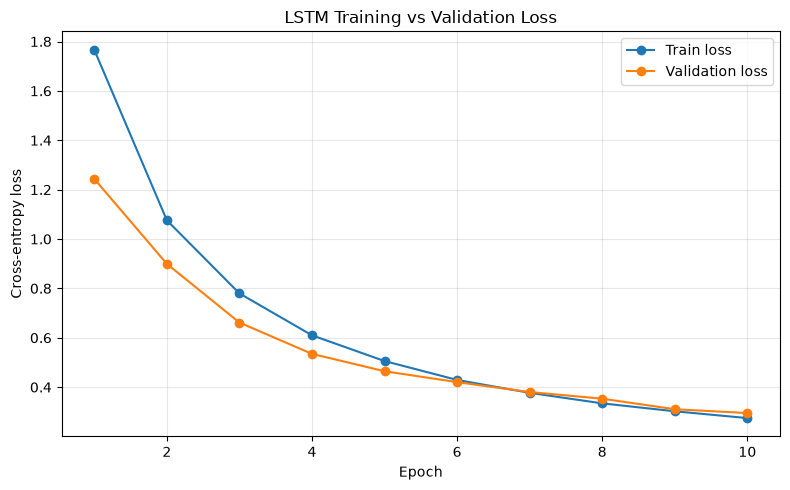

In [1]:
import matplotlib.pyplot as plt

train_losses = [1.7666, 1.0760, 0.7798, 0.6100, 0.5057, 0.4292, 0.3770, 0.3343, 0.3022, 0.2747]
val_losses   = [1.2436, 0.8994, 0.6618, 0.5348, 0.4645, 0.4203, 0.3801, 0.3532, 0.3106, 0.2950]
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve_lstm.png", dpi=150)
plt.show()